# **Задание 1**

На основе открытых источников данных реализуйте прогноз цен на нефть Brent до конца 2027 года

*Ознакомьтесь с лучшими подходами и практиками, используйте различные методы прогнозирования, не ограничиваясь авторегрессией*

In [1]:
!pip install catboost -q

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import yfinance as yf

from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.tsa.statespace.sarimax import SARIMAX

from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error
from catboost import CatBoostRegressor

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 7.2 MB/s eta 0:00:00
Все библиотеки успешно импортированы!


In [2]:
#Brent (таргет), WTI (спред), DXY (доллар), S&P 500 (мировой спрос)
TICKERS = {
    'BZ=F': 'Brent',
    'CL=F': 'WTI',
    'DX-Y.NYB': 'DXY',
    '^GSPC': 'SP500'
}

raw_data = yf.download(
    list(TICKERS.keys()),
    start="2005-01-01",
    auto_adjust=False,
    progress=False
)['Close'].rename(columns=TICKERS)

monthly_data = raw_data.ffill().resample('ME').mean().dropna()

print(f"Загружено: {len(monthly_data)} месяцев")
monthly_data.tail(3)

Загружено: 232 месяцев


Ticker,Brent,WTI,DXY,SP500
Date,,,,
2026-08-31,88.075714,82.452381,99.503810,7711.323335
2026-09-30,102.256666,95.687144,100.070476,7669.414295
2026-10-31,102.279999,91.990002,102.014999,7694.585205


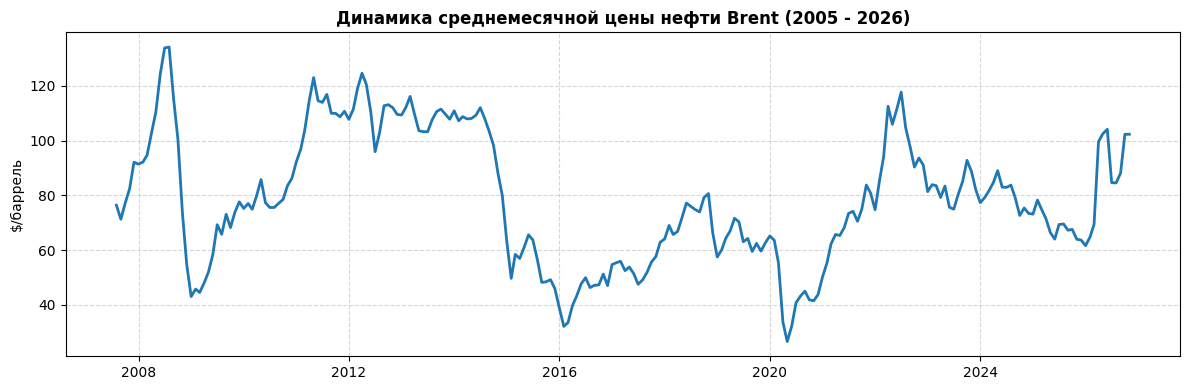


Корреляция между активами:


Ticker,Brent,WTI,DXY,SP500
Ticker,,,,
Brent,1.000000,0.980000,-0.460000,-0.100000
WTI,0.980000,1.000000,-0.460000,-0.080000
DXY,-0.460000,-0.460000,1.000000,0.730000
SP500,-0.100000,-0.080000,0.730000,1.000000



Результаты тестов на стационарность:


,Статистика,p-value,H0 (Нулевая гипотеза),Итог (5%)
Тест,,,,
ADF (Дики-Фуллер),-3.1329,0.0242,Ряд нестационарен,✅ Стационарен
KPSS,0.3673,0.0912,Ряд стационарен,✅ Стационарен


In [3]:

plt.figure(figsize=(12, 4), dpi=100)
plt.plot(monthly_data.index, monthly_data['Brent'], color='#1f77b4', linewidth=2)
plt.title('Динамика среднемесячной цены нефти Brent (2005 - 2026)', fontsize=12, fontweight='bold')
plt.ylabel('$/баррель')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

print("\nКорреляция между активами:")
display(monthly_data.corr().round(2).style.background_gradient(cmap='coolwarm', vmin=-1, vmax=1))

def test_stationarity(series):
    s = series.dropna()
    adf_stat, adf_p, *_ = adfuller(s)
    kpss_stat, kpss_p, *_ = kpss(s, regression='c')

    return pd.DataFrame({
        'Тест': ['ADF (Дики-Фуллер)', 'KPSS'],
        'Статистика': [round(adf_stat, 4), round(kpss_stat, 4)],
        'p-value': [round(adf_p, 4), round(kpss_p, 4)],
        'H0 (Нулевая гипотеза)': ['Ряд нестационарен', 'Ряд стационарен'],
        'Итог (5%)': [
            '✅ Стационарен' if adf_p < 0.05 else '❌ Нестационарен',
            '✅ Стационарен' if kpss_p >= 0.05 else '❌ Нестационарен'
        ]
    }).set_index('Тест')

print("\nРезультаты тестов на стационарность:")
display(test_stationarity(monthly_data['Brent']))

In [5]:
df = monthly_data.copy()
df['log_p'] = np.log(df['Brent'])

df['dev_ma36'] = df['log_p'] - df['log_p'].rolling(36, min_periods=24).mean()
spread = df['Brent'] - df['WTI']
df['spread_clean'] = spread.clip(spread.quantile(0.01), spread.quantile(0.99))
df['dxy_ret_3m'] = np.log(df['DXY']).diff(3)
df['vol_12m'] = df['log_p'].diff(1).rolling(12).std()

features = ['dev_ma36', 'spread_clean', 'dxy_ret_3m', 'vol_12m']

HORIZON = 14
for h in range(1, HORIZON + 1):
    df[f'target_h{h}'] = df['log_p'].shift(-h) - df['log_p']

inference_row = df.iloc[[-1]][features].copy()
inference_last_price = df['Brent'].iloc[-1]
df_clean = df.dropna(subset=features).copy()


In [8]:
# 1. Тест
origin_idx = len(df_clean) - HORIZON - 1
origin_date = df_clean.index[origin_idx]
base_price = df_clean['Brent'].iloc[origin_idx]
y_test = df_clean['Brent'].iloc[origin_idx + 1 : origin_idx + 1 + HORIZON].values
X_test_point = df_clean.loc[[origin_date], features]

# 2. SARIMAX(1,1,1)
train_log = df_clean.iloc[:origin_idx + 1]['log_p']
sarima = SARIMAX(train_log, order=(1, 1, 1), enforce_stationarity=False).fit(disp=False)
sarima_preds = base_price * np.exp(sarima.forecast(HORIZON) - train_log.iloc[-1]).values

# 3. Др. модели
ridge_preds, cb_preds = [], []
for h in range(1, HORIZON + 1):
    tr = df_clean.iloc[: origin_idx - h + 1].dropna(subset=[f'target_h{h}'])
    X_tr, y_tr = tr[features], tr[f'target_h{h}']

    # Ridge
    pipe = make_pipeline(StandardScaler(), Ridge(alpha=20.0)).fit(X_tr, y_tr)
    ridge_preds.append(base_price * np.exp(pipe.predict(X_test_point)[0]))

    # CatBoost
    cb = CatBoostRegressor(iterations=80, depth=2, learning_rate=0.03, l2_leaf_reg=10.0, random_seed=42, verbose=0).fit(X_tr, y_tr)
    cb_preds.append(base_price * np.exp(cb.predict(X_test_point)[0]))

models = {
    '0. Naive': np.full(HORIZON, base_price),
    '1. SARIMAX': sarima_preds,
    '2. Scaled Ridge': np.array(ridge_preds),
    '3. CatBoost': np.array(cb_preds)
}

rmse_naive = np.sqrt(mean_squared_error(y_test, models['0. Naive']))
summary = []
for name, p in models.items():
    rmse = np.sqrt(mean_squared_error(y_test, p))
    summary.append({
        'Модель': name,
        'RMSE ($)': round(rmse, 2),
        'MAE ($)': round(mean_absolute_error(y_test, p), 2),
        'MAPE (%)': round(mean_absolute_percentage_error(y_test, p) * 100, 2),
        'Skill vs Naive (%)': round((1 - rmse / rmse_naive) * 100, 2)
    })

pd.DataFrame(summary).set_index('Модель')

,RMSE ($),MAE ($),MAPE (%),Skill vs Naive (%)
Модель,,,,
0. Naive,22.66,17.66,18.75,0.00
1. SARIMAX,23.01,17.88,18.94,-1.54
2. Scaled Ridge,23.78,18.42,19.48,-4.92
3. CatBoost,17.58,13.71,14.71,22.44


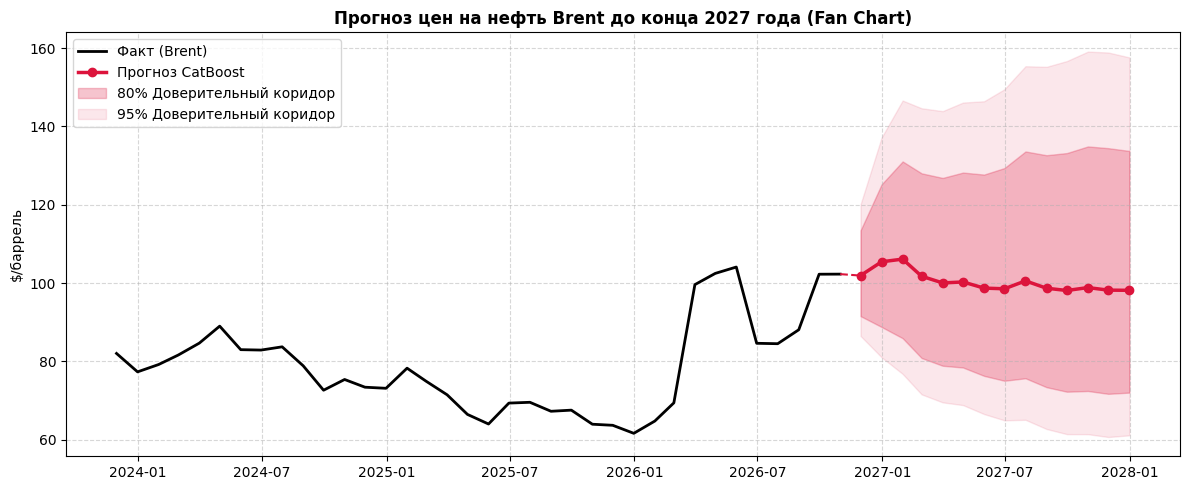

,Месяц,Прогноз Brent ($),Нижняя 80%,Верхняя 80%,Нижняя 95%,Верхняя 95%
0,2026-11,101.91,91.56,113.43,86.49,120.07
1,2026-12,105.43,88.79,125.19,81.05,137.15
2,2027-01,106.12,85.92,131.05,76.81,146.60
3,2027-02,101.74,80.86,128.01,71.57,144.63
4,2027-03,100.03,78.89,126.84,69.54,143.90
5,2027-04,100.28,78.43,128.21,68.84,146.09
6,2027-05,98.71,76.30,127.70,66.55,146.42
7,2027-06,98.54,75.06,129.36,64.95,149.49
8,2027-07,100.56,75.69,133.60,65.08,155.36
9,2027-08,98.68,73.41,132.64,62.74,155.21



Среднегодовая прогнозная цена на 2027 год: $99.83/bbl


In [9]:
# 1. Динамические даты
future_dates = pd.date_range(df_clean.index[-1] + pd.DateOffset(months=1), periods=HORIZON, freq='ME')
preds_log, sigmas = [], []

for h in range(1, HORIZON + 1):
    tr = df_clean.dropna(subset=[f'target_h{h}'])
    cb = CatBoostRegressor(iterations=80, depth=2, learning_rate=0.03, l2_leaf_reg=10.0, random_seed=42, verbose=0).fit(tr[features], tr[f'target_h{h}'])

    preds_log.append(cb.predict(inference_row[features])[0])
    sigmas.append(np.std(tr[f'target_h{h}'] - cb.predict(tr[features])))

preds_log, sigmas = np.array(preds_log), np.array(sigmas)

# 2. Восстановление цен и диапазоны
forecast = inference_last_price * np.exp(preds_log)
low_80, high_80 = inference_last_price * np.exp(preds_log - 1.28 * sigmas), inference_last_price * np.exp(preds_log + 1.28 * sigmas)
low_95, high_95 = inference_last_price * np.exp(preds_log - 1.96 * sigmas), inference_last_price * np.exp(preds_log + 1.96 * sigmas)

# 3. График
plt.figure(figsize=(12, 5), dpi=100)
hist = df_clean['Brent'].iloc[-36:]

plt.plot(hist.index, hist, 'black', lw=2, label='Факт (Brent)')
plt.plot(future_dates, forecast, color='crimson', lw=2.5, marker='o', label='Прогноз CatBoost')
plt.plot([hist.index[-1], future_dates[0]], [hist.iloc[-1], forecast[0]], 'crimson', ls='--')
plt.fill_between(future_dates, low_80, high_80, color='crimson', alpha=0.25, label='80% Доверительный коридор')
plt.fill_between(future_dates, low_95, high_95, color='crimson', alpha=0.10, label='95% Доверительный коридор')

plt.title('Прогноз цен на нефть Brent до конца 2027 года (Fan Chart)', fontweight='bold')
plt.ylabel('$/баррель')
plt.grid(True, ls='--', alpha=0.5)
plt.legend(loc='upper left')
plt.tight_layout()
plt.show()

forecast_res = pd.DataFrame({
    'Месяц': future_dates.strftime('%Y-%m'),
    'Прогноз Brent ($)': np.round(forecast, 2),
    'Нижняя 80%': np.round(low_80, 2),
    'Верхняя 80%': np.round(high_80, 2),
    'Нижняя 95%': np.round(low_95, 2),
    'Верхняя 95%': np.round(high_95, 2)
})
display(forecast_res)
print(f"\nСреднегодовая прогнозная цена на 2027 год: ${forecast_res['Прогноз Brent ($)'].iloc[2:].mean():.2f}/bbl")